# Laboratorio 7

- Mathew Alexander Cordero Aquino - 22982
- Gustavo Adolfo Cruz Bardales - 22779
- Edwin de Leon - 22809

[Link Repositorio](https://github.com/donmatthiuz/VIC/tree/lab7)

## Task 1

### Pregunta 1.1

---

### 1. ¿Qué es Data Augmentation y por qué no son datos falsos?

**Respuesta:**

El Data Augmentation consiste en tomar radiografías reales que ya existen y aplicarles ligeras variaciones visuales, como girar la imagen unos pocos grados, hacer un pequeño zoom, o ajustar el brillo y el contraste. La información médica contenida en la imagen sigue siendo 100% real; lo único que cambia es la forma en que se presenta.

Una analogía útil sería enseñar a un niño a reconocer un carro usando una sola fotografía tomada de frente y con buena iluminación. Si el niño memoriza solo esa imagen, no reconocerá el mismo carro si lo ve de lado, en la noche o sucio.  

El objetivo del Data Augmentation es evitar que el modelo memorice imágenes específicas y, en cambio, aprenda a identificar patrones médicos reales. Así se prepara mejor para situaciones del mundo real, donde las radiografías pueden variar en posición, iluminación o calidad.

---

### 2. Transformaciones válidas e inválidas en radiografías de tórax

**Respuesta:**

**Transformaciones válidas:**
- **Rotaciones leves (±5°):** Simulan variaciones reales en la postura del paciente al momento de la toma.
- **Ajustes de brillo y contraste:** Representan diferencias entre máquinas de rayos X o condiciones de adquisición.
- **Zoom (acercamiento):** Permite enfocar regiones específicas relevantes para el diagnóstico.

**Transformación no válida:**
- **Distorsión geométrica:** Altera las proporciones del cuerpo humano, lo que puede llevar a interpretaciones anatómicas incorrectas y comprometer el diagnóstico.

---

### 3. ¿Es suficiente el Data Augmentation?

**Respuesta:**

No. El Data Augmentation ayuda, pero no es suficiente por sí solo para garantizar una buena generalización.

Debe combinarse con otras técnicas como:
- **Early Stopping:** Detiene el entrenamiento cuando el modelo deja de generalizar.
- **Transfer Learning:** Aprovecha modelos preentrenados para mejorar el aprendizaje con pocos datos.
- **Dropout:** Evita que la red dependa de patrones específicos apagando neuronas durante el entrenamiento.

---

### 4. ¿Cuándo comienza el sobreajuste?

**Respuesta:**

El sobreajuste comienza aproximadamente en la **época 15**.

Se evidencia porque:
- La pérdida de entrenamiento sigue disminuyendo.
- La pérdida de validación comienza a aumentar.

Ejemplo:
- Época 15: entrenamiento = 0.18, validación = 0.42  
- Época 25: entrenamiento = 0.04, validación = 0.89  

Esto indica que el modelo memoriza los datos de entrenamiento pero pierde capacidad de generalización.

---

### 5. Estrategias de regularización

**Respuesta:**

- **Dropout:**
  - Mitiga la *co-adaptación* entre neuronas.
  - Obliga al modelo a aprender patrones más generales.
  - Resultado esperado: menor diferencia entre entrenamiento y validación.

- **Regularización L2:**
  - Penaliza pesos grandes en el modelo.
  - Evita funciones demasiado complejas.
  - Resultado esperado: curvas más suaves y paralelas, sin divergencia fuerte.

---

### 6. Riesgos médicos del sobreajuste

**Respuesta:**

Un modelo sobreajustado no aprende la enfermedad, sino detalles irrelevantes de los datos de entrenamiento (como artefactos o iluminación).

En producción, esto puede causar:
- Diagnósticos incorrectos.
- Falsos negativos (pacientes enfermos diagnosticados como sanos).
- Riesgos graves para la vida del paciente.

---

### 7. Accuracy de un modelo naive

**Respuesta:**

Total de imágenes:
- 700 normales  
- 150 con neumonía  
- Total = 850  

Modelo naive (siempre predice "Normal"):

$$
Accuracy = \frac{700}{850} = 0.8235 \approx 82.35\%
$$

Esto demuestra que el 94% reportado puede ser engañoso, ya que el punto de partida ya es alto sin aprendizaje real.

---

### 8. Métricas más importantes que el accuracy

**Respuesta:**

En problemas médicos con clases desbalanceadas:
- El **accuracy** puede ser engañoso.
- El **Recall (Sensibilidad)** mide cuántos enfermos reales se detectan correctamente.
- El **F1-Score** equilibra precisión y recall.

**Relevancia clínica:**
Es más peligroso un falso negativo (no detectar enfermedad) que un falso positivo. Detectar todos los casos posibles es prioritario, incluso si implica algunas alarmas falsas.

---

### 9. Respuesta al inversionista

**Respuesta:**

Ese 94% de precisión general suena muy positivo, pero puede ser engañoso debido a que la mayoría de las radiografías corresponden a pacientes sanos. De hecho, un modelo que siempre prediga “normal” ya alcanzaría más del 82% de acierto sin ningún aprendizaje real. Por eso, para validar el sistema de forma confiable, utilizamos métricas clínicas más específicas que nos indican qué tan bien detectamos los casos reales de neumonía. Nuestro enfoque prioriza la seguridad del paciente, asegurando que el modelo minimice los errores críticos en diagnóstico.

## Task 2


### Pregunta 2.1 
- No estoy de acuerdo con la afirmación del desarrollador. Aunque ImageNet 
contiene imágenes naturales como perros, gatos y automóviles, las capas 
convolucionales iniciales de una red neuronal aprenden características 
generales como bordes, texturas y patrones de intensidad que son comunes a 
muchos tipos de imágenes, incluyendo radiografías, este conocimiento es 
transferible entre dominios visualmente distintos.  
Lo que sí cambia es la especialización de las capas más profundas, que 
aprenden patrones específicos del dominio. Por lo tanto, el Transfer Learning 
sigue siendo útil incluso en imágenes médicas en escala de grises.  

- El costo de entrenar un modelo desde cero para una startup como MediScan 
Guatemala es alto en múltiples dimensiones. En términos de computación, 
requiere acceso a hardware especializado como GPUs o TPUs durante largos 
periodos.  
En cuanto al tiempo, el desarrollo se alarga considerablemente, lo que retrasa 
la salida al mercado. También existe un alto riesgo de sobreajuste debido al 
tamaño limitado del dataset (800 imágenes), lo que compromete la calidad del 
modelo, además, se necesita talento humano altamente especializado en 
deep learning, lo cual incrementa los costos operativos, en conjunto, entrenar 
desde cero es una estrategia ineficiente y riesgosa en este contexto.  

- Sí existen escenarios donde entrenar desde cero es válido. Esto ocurre cuando 
se dispone de un dataset muy grande, por ejemplo millones de imágenes 
médicas, o cuando el dominio es extremadamente distinto a los datos de 
preentrenamiento, como imágenes térmicas o espectrales.  
También puede ser necesario si se requiere una arquitectura altamente 
especializada para una tarea médica específica, sin embargo en el caso de 
MediScan Guatemala, con solo 800 imágenes, no es recomendable entrenar 
desde cero.  
 
 
 
 
### Pregunta 2.2 
- Recomiendo la Opción A, que consiste en congelar toda la red base y entrenar 
únicamente el cabezal final, esto se debe a que el dataset es pequeño, lo que 
aumenta el riesgo de sobreajuste si se entrenan demasiados parámetros.  
Al congelar la red base, se aprovechan las características generales ya 
aprendidas y se limita el entrenamiento a la capa final, lo que mejora la 
generalización, la lógica detrás de esta decisión es que, con pocos datos, es 
preferible reducir la cantidad de parámetros entrenables para evitar que el 
modelo memorice en lugar de aprender.  

- Si se aplica la Opción B con una tasa de aprendizaje alta (por ejemplo 1e-3) en 
toda la red, se corre el riesgo de provocar el fenómeno conocido como 
“catastrophic forgetting”.  
Esto significa que el modelo pierde el conocimiento previamente aprendido 
durante el preentrenamiento, durante el entrenamiento, este problema se 
evidenciaría con una pérdida inestable, una precisión baja o decreciente, y un 
comportamiento errático del modelo, en general, el modelo dejaría de 
aprovechar el conocimiento transferido y su rendimiento se deterioraría.  

- Si MediScan Guatemala logra recolectar 50,000 radiografías etiquetadas, la 
estrategia debería cambiar, en este caso, se puede aplicar fine-tuning de 
manera más agresiva, descongelando parcialmente la red, especialmente las 
capas más profundas.  
Se recomienda utilizar tasas de aprendizaje bajas (como 1e-5 o 1e-4) y realizar 
un ajuste progresivo, la evolución natural de la estrategia es pasar de congelar 
la red con pocos datos a entrenar más capas conforme aumenta la cantidad 
de información disponible.  
 
### Pregunta 2.3 
- Sí es viable reutilizar el modelo de neumonía para el nuevo problema de 
detección de fracturas en radiografías de muñeca, las capas iniciales del 
modelo capturan características básicas como bordes y estructuras, mientras 
que las capas intermedias pueden representar patrones radiológicos 
generales.  
Sin embargo, las capas finales, que están especializadas en neumonía, deben 
ser modificadas. Por lo tanto, se puede reutilizar gran parte del modelo, pero 
es necesario adaptar las capas finales al nuevo problema.  

- Un plan de acción adecuado para adaptar el modelo sería el siguiente: 
primero, cargar el modelo preentrenado en neumonía; segundo, reemplazar la 
capa final por una nueva adaptada a la clasificación de fracturas; tercero, 
congelar las capas base inicialmente; cuarto, entrenar el nuevo cabezal; 
quinto, descongelar progresivamente las últimas capas para ajustar el modelo 
al nuevo dominio.  
 finalmente, utilizar una tasa de aprendizaje baja (por ejemplo 1e-5) para evitar 
degradar el conocimiento previo, este enfoque permite una adaptación 
eficiente sin perder lo aprendido anteriormente.  

- El principal riesgo ético y clínico de reutilizar un modelo sin validación rigurosa 
es la generación de diagnósticos incorrectos, como falsos negativos o falsos 
positivos, que pueden afectar directamente la salud del paciente. Por ejemplo, 
no detectar una fractura podría retrasar el tratamiento adecuado.  
Para mitigar este riesgo, se recomienda un proceso de validación mínimo que 
incluya la división del dataset en entrenamiento, validación y prueba, el uso de 
validación cruzada, la evaluación con métricas clínicas como sensibilidad y 
especificidad, la revisión por profesionales médicos y pruebas piloto antes del 
despliegue en un entorno real, en el ámbito médico, la validación rigurosa es 
indispensable antes de implementar cualquier sistema automatizado.

## Task 3

### Entorno de ejecución y Carga de Dataset

#### GPU

Verificamos que la GPU funciona

In [ ]:
import subprocess, sys

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "⚠ GPU no disponible. Verificar configuración de Colab.")

import torch
print(f"\n PyTorch versión : {torch.__version__}")
print(f" CUDA disponible  : {torch.cuda.is_available()}")
print(f" Dispositivo GPU  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f" VRAM disponible  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
      if torch.cuda.is_available() else "")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n→ DEVICE global    : {DEVICE}")

Sun Mar 22 21:05:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### Drive

Usamos drive para persistir resultados.

In [ ]:
from google.colab import drive
import os, pathlib


drive.mount("/content/drive", force_remount=False)

# ── Estructura de carpetas del proyecto ────────────────────
# MyDrive/
#   pneumonia_project/
#     checkpoints/   ← pesos .pt guardados por epoch
#     models/        ← modelos finales .pt
#     metrics/       ← CSV con historial de entrenamiento
#     results/       ← matrices de confusión, curvas ROC
#     data/          ← dataset descomprimido (opcional)
# ──────────────────────────────────────────────────────────

BASE_DIR    = pathlib.Path("/content/drive/MyDrive/pneumonia_project")
CKPT_DIR    = BASE_DIR / "checkpoints"
MODEL_DIR   = BASE_DIR / "models"
METRICS_DIR = BASE_DIR / "metrics"
RESULTS_DIR = BASE_DIR / "results"
DATA_DIR    = BASE_DIR / "data"

for folder in [CKPT_DIR, MODEL_DIR, METRICS_DIR, RESULTS_DIR, DATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f" {folder}")

print("\n Google Drive montado y estructura de carpetas lista.")

Mounted at /content/drive
 /content/drive/MyDrive/pneumonia_project/checkpoints
 /content/drive/MyDrive/pneumonia_project/models
 /content/drive/MyDrive/pneumonia_project/metrics
 /content/drive/MyDrive/pneumonia_project/results
 /content/drive/MyDrive/pneumonia_project/data

 Google Drive montado y estructura de carpetas lista.


#### Kaggle

Cargamos los datos de kaggle

In [ ]:
import kagglehub, os
from pathlib import Path

KAGGLE_PATH = Path(kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
))
print(f" Dataset en: {KAGGLE_PATH}")


candidates = list(KAGGLE_PATH.rglob("chest_xray"))
if candidates:
    XRAY_ROOT = candidates[0]
else:
    XRAY_ROOT = KAGGLE_PATH

print(f" XRAY_ROOT       : {XRAY_ROOT}")

for split in ["train", "val", "test"]:
    p = XRAY_ROOT / split
    if p.exists():
        normal    = len(list((p / "NORMAL").glob("*.jpeg")))
        pneumonia = len(list((p / "PNEUMONIA").glob("*.jpeg")))
        print(f"  {split:6s}  NORMAL: {normal:4d} | PNEUMONIA: {pneumonia:4d} | total: {normal+pneumonia:4d}")
    else:
        print(f"  ⚠ {split} no encontrado en {p}")


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
 Dataset en: /kaggle/input/chest-xray-pneumonia
 XRAY_ROOT       : /kaggle/input/chest-xray-pneumonia/chest_xray
  train   NORMAL: 1341 | PNEUMONIA: 3875 | total: 5216
  val     NORMAL:    8 | PNEUMONIA:    8 | total:   16
  test    NORMAL:  234 | PNEUMONIA:  390 | total:  624


#### Importaciones

Aqui definimos los imports y las constantes a usar.

In [ ]:
import os, sys, time, json, shutil, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams["figure.dpi"] = 120

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, ConcatDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision
from torchvision import datasets, models
from torchvision.transforms import v2 as T
from torchvision.models import (
    resnet50,      ResNet50_Weights,
    mobilenet_v2,  MobileNet_V2_Weights,
    densenet121,   DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split

import kagglehub

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(" Imports cargados.")
print(f" PyTorch {torch.__version__} | Torchvision {torchvision.__version__}")
print(f" DEVICE: {DEVICE} | SEED: {SEED}")


IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-4
LR_FINETUNE = 1e-5
PATIENCE    = 5
NUM_WORKERS = 2
PIN_MEMORY  = torch.cuda.is_available()

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
NUM_CLASSES = 2
POS_CLASS   = 1

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(" Configuración global lista.")
print(f"  IMG={IMG_SIZE} | BATCH={BATCH_SIZE} | LR={LR} | EPOCHS={NUM_EPOCHS} | PATIENCE={PATIENCE}")
print(f"  SPLIT   train={TRAIN_RATIO} / val={VAL_RATIO} / test={TEST_RATIO}")
print(f"  CLASES  {CLASS_NAMES} (positiva: idx {POS_CLASS})")

 Imports cargados.
 PyTorch 2.10.0+cu128 | Torchvision 0.25.0+cu128
 DEVICE: cuda | SEED: 42
 Configuración global lista.
  IMG=224 | BATCH=32 | LR=0.0001 | EPOCHS=30 | PATIENCE=5
  SPLIT   train=0.7 / val=0.15 / test=0.15
  CLASES  ['NORMAL', 'PNEUMONIA'] (positiva: idx 1)


#### Estratificación

In [ ]:
from sklearn.model_selection import train_test_split
from torchvision import datasets


ds_train = datasets.ImageFolder(root=XRAY_ROOT / "train")
ds_val   = datasets.ImageFolder(root=XRAY_ROOT / "val")
ds_test  = datasets.ImageFolder(root=XRAY_ROOT / "test")

all_samples = ds_train.samples + ds_val.samples + ds_test.samples
all_paths   = [s[0] for s in all_samples]
all_labels  = [s[1] for s in all_samples]

print(f"Pool total  : {len(all_paths)} imágenes")
print(f"  NORMAL    : {all_labels.count(0)}")
print(f"  PNEUMONIA : {all_labels.count(1)}")


paths_train, paths_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)


paths_val, paths_test, y_val, y_test = train_test_split(
    paths_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("\nSplit        NORMAL   PNEUMONIA   Total   % pneumonia")
for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    n = labels.count(0)
    p = labels.count(1)
    print(f"{name:8s}   {n:6d}   {p:9d}   {n+p:5d}   {p/(n+p)*100:.1f}%")

Pool total  : 5856 imágenes
  NORMAL    : 1583
  PNEUMONIA : 4273

Split        NORMAL   PNEUMONIA   Total   % pneumonia
train        1108        2991    4099   73.0%
val           237         641     878   73.0%
test          238         641     879   72.9%


### Dataumentation



In [ ]:
import random
from torchvision.transforms import v2 as T
import torch

class MedicalRandAugment:

    def __init__(self, num_ops=2, seed=None):
        self.num_ops = num_ops
        self.rng = random.Random(seed)
        self.pool = [
            ("h_flip",       T.RandomHorizontalFlip(p=1.0)),
            ("rotation",     T.RandomRotation(degrees=10)),

            ("affine",       T.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5)),
            ("crop",         T.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.85, 1.0), ratio=(0.9, 1.1))),
            ("perspective",  T.RandomPerspective(distortion_scale=0.1, p=1.0)),
            ("color_jitter", T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0)),
            ("autocontrast", T.RandomAutocontrast()),
            ("equalize",     T.RandomEqualize()),


            ("sharpness",    T.RandomAdjustSharpness(sharpness_factor=2)),



            ("blur",         T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))),



        ]

    def __call__(self, img):
        ops = self.rng.sample(self.pool, self.num_ops)
        for _, op in ops:
            img = op(img)
        return img

    def __repr__(self):
        names = [n for n, _ in self.pool]
        return f"MedicalRandAugment(num_ops={self.num_ops}, pool={names})"


train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    MedicalRandAugment(num_ops=2),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
])

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(train_transforms)
print(f"\nPool : 10 transforms clínicamente válidas")
print(f"Ops  : 2 sorteadas por imagen → 45 combinaciones posibles")
print(f"RandomErasing siempre después de Normalize")






Compose(
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      MedicalRandAugment(num_ops=2, pool=['h_flip', 'rotation', 'affine', 'crop', 'perspective', 'color_jitter', 'autocontrast', 'equalize', 'sharpness', 'blur'])
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
      RandomErasing(p=0.15, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=[0.0], inplace=False)
)

Pool : 10 transforms clínicamente válidas
Ops  : 2 sorteadas por imagen → 45 combinaciones posibles
RandomErasing siempre después de Normalize


#### Prueba de Data Aumentation


Shape  : torch.Size([4, 3, 224, 224])
Dtype  : torch.float32
Min    : -2.12
Max    : 2.64
Labels : [1, 1, 0, 1]
Clases : ['NORMAL', 'PNEUMONIA']


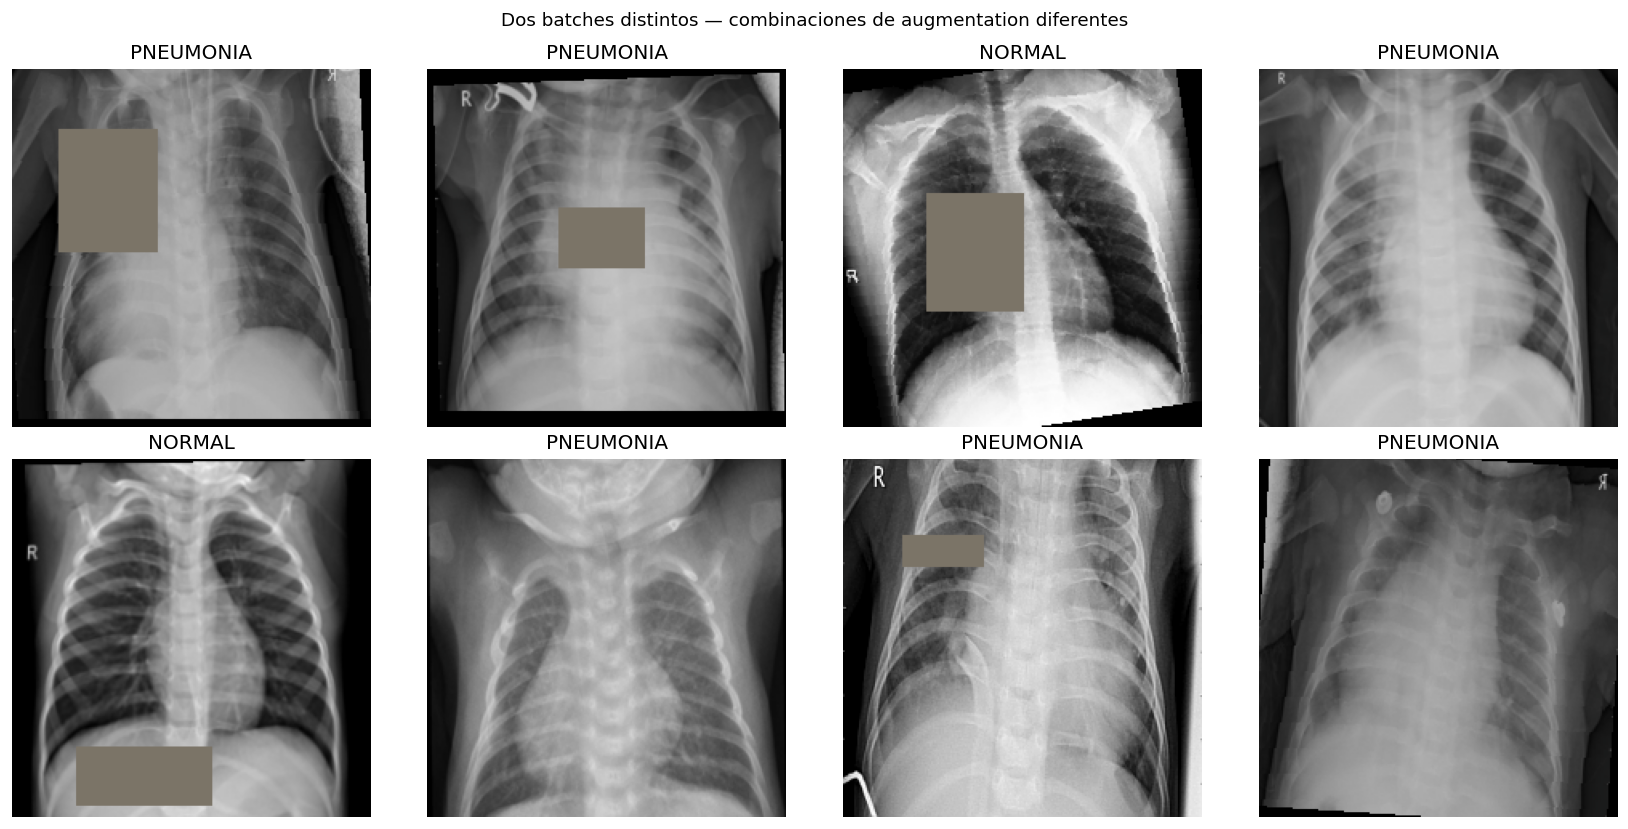

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

ds_prueba = datasets.ImageFolder(root=XRAY_ROOT / "train", transform=train_transforms)
loader_prueba = DataLoader(ds_prueba, batch_size=4, shuffle=True)
imgs, labels = next(iter(loader_prueba))

print(f"Shape  : {imgs.shape}")        # [4, 3, 224, 224]
print(f"Dtype  : {imgs.dtype}")        # torch.float32
print(f"Min    : {imgs.min():.2f}")    # aprox -2.1
print(f"Max    : {imgs.max():.2f}")    # aprox  2.6
print(f"Labels : {labels.tolist()}")
print(f"Clases : {ds_prueba.classes}") # ['NORMAL', 'PNEUMONIA']

mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std  = torch.tensor(IMAGENET_STD).view(3,1,1)
imgs_vis = (imgs * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    axes[0, i].imshow(imgs_vis[i].permute(1, 2, 0), cmap="gray")
    axes[0, i].set_title(ds_prueba.classes[labels[i]])
    axes[0, i].axis("off")

imgs2, labels2 = next(iter(loader_prueba))
imgs_vis2 = (imgs2 * std + mean).clamp(0, 1)
for i in range(4):
    axes[1, i].imshow(imgs_vis2[i].permute(1, 2, 0), cmap="gray")
    axes[1, i].set_title(ds_prueba.classes[labels2[i]])
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Batch 1", fontsize=10)
axes[1, 0].set_ylabel("Batch 2", fontsize=10)
plt.suptitle("Dos batches distintos — combinaciones de augmentation diferentes", fontsize=11)
plt.tight_layout()
plt.show()

### Modelos


#### Creación



**ResNet50**

In [ ]:

def build_resnet50(num_classes=2, freeze_base=True):
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes),
    )
    return model


**MobileNet**

In [ ]:

def build_mobilenetv2(num_classes=2, freeze_base=True):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


**Justificación**

In [ ]:




def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    return total, trainable, frozen


resnet   = build_resnet50().to(DEVICE)
mobilenet = build_mobilenetv2().to(DEVICE)

for name, model in [("ResNet50", resnet), ("MobileNetV2", mobilenet)]:
    total, trainable, frozen = count_params(model)
    print(f"{name}")
    print(f"  Total params     : {total:,}")
    print(f"  Entrenables      : {trainable:,}   solo el cabezal")
    print(f"  Congelados        : {frozen:,}   base ImageNet")

    print()

ResNet50
  Total params     : 24,033,090
  Entrenables      : 525,058  ← solo el cabezal
  Congelados        : 23,508,032  ← base ImageNet

MobileNetV2
  Total params     : 2,552,322
  Entrenables      : 328,450  ← solo el cabezal
  Congelados        : 2,223,872  ← base ImageNet




- **Modelos Usados:**
  Aqui utilizamos ResNet Y Mobile Net esto porque ResNet es pesado y preciso y  MobileNet es mas liviano para dispositivos electronicos.

  Eso hace la comparación interesante para el dictamen ejecutivo sobre hardware limitado en clínicas rurales.

- **Pesos Congelados:** Congelamos toda la base porque ImageNet ya aprendieron detectores de bordes, texturas y patrones generales que son útiles para cualquier imagen incluyendo radiografías. Si los descongelamos puede provocar un overfitting no deseado.

- **Uso de capas**:  El cabezal si ves tiene Linear→ReLU→Dropout→Linear, se usaron 256 neuronas porque ResNet50 entrega 2048 features, MobileNetV2 entrega 1280. Ir directo a 2 es un salto de 1000x. 256 es un punto intermedio, reduce progresivamente sin colapsar toda la información de golpe. Asi evitamos que la dimensionalidad explote.



#### Data Loader

In [ ]:
class XRayDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_ds = XRayDataset(paths_train, y_train, transform=train_transforms)
val_ds   = XRayDataset(paths_val,   y_val,   transform=val_test_transforms)
test_ds  = XRayDataset(paths_test,  y_test,  transform=val_test_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"train : {len(train_ds):4d} imgs | {len(train_loader):3d} batches")
print(f"val   : {len(val_ds):4d} imgs | {len(val_loader):3d} batches")
print(f"test  : {len(test_ds):4d} imgs | {len(test_loader):3d} batches")

train : 4099 imgs | 129 batches
val   :  878 imgs |  28 batches
test  :  879 imgs |  28 batches


#### Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, path="best_model.pt"):
        self.patience  = patience
        self.path      = path
        self.counter   = 0
        self.best_loss = None
        self.stop      = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
            print(f"  ✓ Mejor val_loss={val_loss:.4f} — modelo guardado en Drive")
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience} — sin mejora")
            if self.counter >= self.patience:
                self.stop = True

#### Entrenar

In [ ]:
def train_model(model, model_name, save_path):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR
    )
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    es        = EarlyStopping(patience=PATIENCE, path=save_path)
    history   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    print(f"\n----------------------------------------------------------------------")
    print(f"  Entrenando : {model_name}")
    print(f"  LR={LR} | BATCH={BATCH_SIZE} | MAX_EPOCHS={NUM_EPOCHS} | PATIENCE={PATIENCE}")
    print(f"----------------------------------------------------------------------")

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_loss, train_correct = 0.0, 0
        total_batches = len(train_loader)

        for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

            if batch_idx % 10 == 0 or batch_idx == total_batches:
                print(f"  Epoch {epoch:02d} | batch {batch_idx:03d}/{total_batches} "
                      f"| loss={loss.item():.4f}", end="\r")

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs    = model(imgs)
                loss       = criterion(outputs, labels)
                val_loss    += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        tl = train_loss    / len(train_ds)
        vl = val_loss      / len(val_ds)
        ta = train_correct / len(train_ds)
        va = val_correct   / len(val_ds)

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
              f"train_loss={tl:.4f} acc={ta:.3f} | "
              f"val_loss={vl:.4f} acc={va:.3f}")

        scheduler.step(vl)
        es(vl, model)
        if es.stop:
            print(f"\n  Detenido en epoch {epoch}. Mejor val_loss={es.best_loss:.4f}")
            break

    model.load_state_dict(torch.load(save_path))

    csv_path = METRICS_DIR / f"{model_name}_history.csv"
    pd.DataFrame(history).to_csv(csv_path, index=False)
    print(f"  History guardado en: {csv_path}")

    return model, history

#### Metricas

In [ ]:
def evaluate_model(model, model_name, save_path):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(DEVICE)
            preds  = model(imgs).argmax(1).cpu().tolist()
            all_preds  += preds
            all_labels += labels.tolist()

    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, pos_label=POS_CLASS)
    recall   = recall_score(all_labels, all_preds, pos_label=POS_CLASS)

    model_mb = os.path.getsize(save_path) / 1e6

    sample_imgs = next(iter(DataLoader(test_ds, batch_size=100)))[0].to(DEVICE)
    times = []
    with torch.no_grad():
        for _ in range(10):
            t0 = time.perf_counter()
            model(sample_imgs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()   # espera GPU antes de medir
            times.append((time.perf_counter() - t0) * 1000)
    inf_ms = np.mean(times[2:])   # descarta 2 primeras (calentamiento CUDA)

    print(f"\n---------------------------------------------------------")
    print(f"  {model_name} — métricas en test")
    print(f"\n---------------------------------------------------------")
    print(f"  Accuracy          : {accuracy*100:.2f}%")
    print(f"  F1 (Neumonía)     : {f1:.4f}")
    print(f"  Recall (Neumonía) : {recall:.4f}")
    print(f"  Tamaño en disco   : {model_mb:.1f} MB")
    print(f"  Inferencia 100img : {inf_ms:.1f} ms")

    metrics = {
        "model"    : model_name,
        "accuracy" : round(accuracy, 4),
        "f1"       : round(f1, 4),
        "recall"   : round(recall, 4),
        "size_mb"  : round(model_mb, 2),
        "inf_ms"   : round(inf_ms, 2),
    }

    csv_path = METRICS_DIR / f"{model_name}_metrics.csv"
    pd.DataFrame([metrics]).to_csv(csv_path, index=False)
    print(f"  Métricas guardadas en: {csv_path}")

    return metrics

### Ejecutar Todo

**ResNet**

In [ ]:
PATH_RESNET = str(MODEL_DIR / "resnet50_best.pt")
resnet, hist_resnet = train_model(resnet, "ResNet50", PATH_RESNET)


----------------------------------------------------------------------
  Entrenando : ResNet50
  LR=0.0001 | BATCH=32 | MAX_EPOCHS=30 | PATIENCE=5
----------------------------------------------------------------------
Epoch 01/30 | train_loss=0.2137 acc=0.916 | val_loss=0.1640 acc=0.937
  ✓ Mejor val_loss=0.1640 — modelo guardado en Drive
Epoch 02/30 | train_loss=0.2023 acc=0.921 | val_loss=0.1579 acc=0.949
  ✓ Mejor val_loss=0.1579 — modelo guardado en Drive
Epoch 03/30 | train_loss=0.1909 acc=0.922 | val_loss=0.1501 acc=0.952
  ✓ Mejor val_loss=0.1501 — modelo guardado en Drive
Epoch 04/30 | train_loss=0.1840 acc=0.933 | val_loss=0.1449 acc=0.956
  ✓ Mejor val_loss=0.1449 — modelo guardado en Drive
Epoch 05/30 | train_loss=0.1839 acc=0.928 | val_loss=0.1398 acc=0.958
  ✓ Mejor val_loss=0.1398 — modelo guardado en Drive
Epoch 06/30 | train_loss=0.1723 acc=0.933 | val_loss=0.1507 acc=0.950
  EarlyStopping: 1/5 — sin mejora
Epoch 07/30 | train_loss=0.1769 acc=0.932 | val_loss=0.1404 ac

In [ ]:
metrics_resnet = evaluate_model(resnet, "ResNet50", PATH_RESNET)


---------------------------------------------------------
  ResNet50 — métricas en test

---------------------------------------------------------
  Accuracy          : 95.45%
  F1 (Neumonía)     : 0.9688
  Recall (Neumonía) : 0.9672
  Tamaño en disco   : 96.5 MB
  Inferencia 100img : 394.4 ms
  Métricas guardadas en: /content/drive/MyDrive/pneumonia_project/metrics/ResNet50_metrics.csv


**MobileNet**

In [29]:
PATH_MOBILENET = str(MODEL_DIR / "mobilenetv2_best.pt")
mobilenet, hist_mobilenet = train_model(mobilenet, "MobileNetV2", PATH_MOBILENET)


----------------------------------------------------------------------
  Entrenando : MobileNetV2
  LR=0.0001 | BATCH=32 | MAX_EPOCHS=30 | PATIENCE=5
----------------------------------------------------------------------
Epoch 01/30 | train_loss=0.2163 acc=0.913 | val_loss=0.1500 acc=0.942
  ✓ Mejor val_loss=0.1500 — modelo guardado en Drive
Epoch 02/30 | train_loss=0.2171 acc=0.910 | val_loss=0.1672 acc=0.932
  EarlyStopping: 1/5 — sin mejora
Epoch 03/30 | train_loss=0.2262 acc=0.903 | val_loss=0.1457 acc=0.944
  ✓ Mejor val_loss=0.1457 — modelo guardado en Drive
Epoch 04/30 | train_loss=0.2176 acc=0.906 | val_loss=0.1459 acc=0.936
  EarlyStopping: 1/5 — sin mejora
Epoch 05/30 | train_loss=0.2162 acc=0.906 | val_loss=0.1442 acc=0.943
  ✓ Mejor val_loss=0.1442 — modelo guardado en Drive
Epoch 06/30 | train_loss=0.2158 acc=0.912 | val_loss=0.1498 acc=0.938
  EarlyStopping: 1/5 — sin mejora
Epoch 07/30 | train_loss=0.2129 acc=0.915 | val_loss=0.1452 acc=0.946
  EarlyStopping: 2/5 — sin 

In [30]:
metrics_mobilenet = evaluate_model(mobilenet, "MobileNetV2", PATH_MOBILENET)


---------------------------------------------------------
  MobileNetV2 — métricas en test

---------------------------------------------------------
  Accuracy          : 94.31%
  F1 (Neumonía)     : 0.9611
  Recall (Neumonía) : 0.9641
  Tamaño en disco   : 10.5 MB
  Inferencia 100img : 119.5 ms
  Métricas guardadas en: /content/drive/MyDrive/pneumonia_project/metrics/MobileNetV2_metrics.csv


### Comparación Final

In [31]:
df_results = pd.DataFrame([metrics_resnet, metrics_mobilenet]).set_index("model")
print(f"\n{'='*60}")
print("  Tabla comparativa final")
print(f"{'='*60}")
print(df_results.to_string())

csv_path = METRICS_DIR / "comparativa_final.csv"
df_results.to_csv(csv_path)
print(f"\nTabla comparativa guardada en: {csv_path}")


  Tabla comparativa final
             accuracy      f1  recall  size_mb  inf_ms
model                                                 
ResNet50       0.9545  0.9688  0.9672    96.45  394.42
MobileNetV2    0.9431  0.9611  0.9641    10.46  119.47

Tabla comparativa guardada en: /content/drive/MyDrive/pneumonia_project/metrics/comparativa_final.csv



# Informe

---

## 1. Introducción

**Contexto del problema:**

La neumonía es una infección respiratoria que puede ser potencialmente mortal si no se detecta y trata a tiempo. En muchos sistemas de salud, especialmente en contextos con recursos limitados, el diagnóstico depende de la interpretación de radiografías de tórax por parte de especialistas, lo cual puede generar retrasos, errores humanos o falta de cobertura en zonas rurales. El uso de modelos de aprendizaje profundo permite automatizar la detección de patrones asociados a la neumonía en imágenes médicas, ofreciendo una herramienta de apoyo para el diagnóstico clínico, mejorando la eficiencia y reduciendo el riesgo de diagnósticos tardíos.


**Objetivo del proyecto:**

Desarrollar y comparar dos modelos de aprendizaje profundo preentrenados (ResNet y MobileNet) adaptados al problema de clasificación binaria de radiografías de tórax (Normal vs Neumonía), evaluando su desempeño mediante métricas como accuracy, F1-score y sensibilidad. Además, se busca analizar su viabilidad para implementación en entornos reales, considerando factores como tamaño del modelo y tiempo de inferencia, con el fin de recomendar una solución adecuada para su uso en sistemas clínicos con recursos limitados.

**Herramientas utilizadas:**

- Framework: PyTorch
- Librerías: Pandas, Matplotlib
- Modelos preentrenados: ResNet, MobileNet

---

## 2. Preparación del Dataset

### 2.1 Descripción del Dataset

* Nombre: Chest X-Ray Images (Pneumonia)
* Fuente: Kaggle

**Número total de imágenes:**

5856


**Distribución de clases:**

* Normal: 1583
* Neumonía:4273

---

### 2.2 División de Datos

* Entrenamiento (70%): 4099   
* Validación (15%): 878   
* Prueba (15%): 879

**¿Se utilizó estratificación?**

Se utilizo estratificación.


**Justificación:**

Se utilizo estratificación debido a que se quiere mantener la misma cantidad por cada clase del dataset, sin esto lo que hubiera pasado es que se tendria un desbalance entre clases y no se podrian confiar en las metricas que arrojara el modelo. 

### 2.3 Data Augmentation

**Transformaciones**

- Color Jitter: Ajustar brillo y contraste.
- Random Autocontrast: Ajustar contraste automáticamente.
- Random Equalize: Ecualizar el histograma.
- Random Adjust Sharpness: Aumentar nitidez.
- Gaussian Blur: Aplicar desenfoque leve.
- Random Erasing: Borrar una parte de la imagen aleatoriamente.
- Normalize: Normalizar valores de píxeles.
- ToImage: Convertir a formato de imagen.
- ToDtype: Convertir a tipo float y escalar valores.



**Justificación:**

Se utilizó esto para poder hacer que el modelo aprenda dentro de un terreno que no es perfecto, además que como contamos con un dataset muy limitado nos sirve para generar ruido y mejorar su capacidad de reconocimiento.

* Resize: Para mantener un tamaño uniforme y que el modelo procese todas las imágenes correctamente.
* Random Horizontal Flip: Para que el modelo no dependa de una orientación específica.
* Random Rotation: Para simular pequeñas variaciones en la posición del paciente.
* Random Affine: Para representar ligeros movimientos o desalineaciones en la captura.
* Random Resized Crop: Para que el modelo aprenda a enfocarse en distintas zonas del pulmón.
* Random Perspective: Para simular cambios leves en el ángulo de la radiografía.
* Color Jitter: Para adaptarse a variaciones de iluminación y contraste entre equipos.
* Random Autocontrast: Para mejorar la visibilidad de patrones sin alterar la información.
* Random Equalize: Para resaltar detalles importantes en distintas condiciones.
* Random Adjust Sharpness: Para adaptarse a imágenes con diferente nivel de nitidez.
* Gaussian Blur: Para que el modelo sea robusto ante imágenes borrosas.
* Random Erasing: Para evitar que el modelo dependa de una sola región específica.
* Normalize: Para adaptar los datos al formato esperado por los modelos preentrenados.
* ToImage: Para asegurar el formato correcto de entrada.
* ToDtype: Para escalar los valores y facilitar el aprendizaje.



## 3. Modelos Utilizados

### 3.1 Modelo 1: ResNet

**Arquitectura base:**

Se utilizó el modelo ResNet50 el cual ha sido previamente entrenado sobre un gran conjunto de imágenes generales.

**Capas congeladas:**

Se congelaron todas las capas de la red base (feature extractor), es decir, no se actualizaron sus pesos durante el entrenamiento.

**Justificación:**

Se hizo esto para aprovechar lo que aprendio el modelo, ademas que se uso ResNet ya que es un modelo que combina presición y tambien optimización evitando caer en el problema del gradiente descendiente, esto porque con datos tan pequeños puede provocar que el modelo solo recuerde pixeles y no generalice bien.




**Nuevo cabezal de clasificación:**

Se reemplazó la capa completamente conectada original del modelo por un nuevo cabezal adaptado al problema de clasificación binaria. Este está compuesto por una capa lineal de 256 neuronas, seguida de una función de activación ReLU, una capa de Dropout con probabilidad de 0.4 para reducir el sobreajuste, y finalmente una capa lineal de salida con 2 neuronas correspondientes a las clases.

### 3.2 Modelo 2: MobileNet

**Arquitectura base:**

Este modelo está diseñado para ser eficiente en términos de tamaño y velocidad, lo que lo hace adecuado para entornos con recursos limitados como dispositivos sin GPU.

**Capas congeladas:**

Se congelaron todas las capas de la red base, evitando la actualización de sus pesos durante el entrenamiento. Solo se entrenó el nuevo cabezal de clasificación.


**Justificación:**

Se decidió congelar la base para aprovechar las características previamente aprendidas y reducir el riesgo de sobreajuste, dado que el dataset es limitado. Además, esto permite entrenar el modelo de manera más rápida y con menor costo computacional.

**Nuevo cabezal de clasificación:**

Se reemplazó la capa clasificadora original por un nuevo cabezal adaptado al problema binario. Este incluye una capa de Dropout con probabilidad de 0.4, seguida de una capa lineal de 256 neuronas, una activación ReLU, otra capa de Dropout de 0.3 para mayor regularización, y finalmente una capa lineal de salida con 2 neuronas correspondientes a las clases.



## 4. Configuración de Entrenamiento

**Función de pérdida:**

Se utilizó CrossEntropyLoss, adecuada para problemas de clasificación multiclase . Esta función combina internamente Softmax y cálculo de pérdida, permitiendo al modelo aprender a diferenciar entre imágenes normales y con neumonía.


**Optimizador:**

Se utilizó el optimizador Adam, aplicado únicamente a los parámetros entrenables del modelo y se uso porque converge rápidamente y se adapta dinámicamente durante el entrenamiento.

**Hiperparámetros:**

* Learning rate: 1e-4
* Batch size: 32
* Épocas: 30


**Justificación:**

El learning rate se estableció en 1e-4, un valor bajo adecuado para modelos preentrenados, ya que permite realizar ajustes finos en el cabezal de clasificación sin alterar drásticamente los pesos aprendidos previamente. Esto es especialmente importante al trabajar con transferencia de aprendizaje.

El batch size se definió en 32, logrando un balance entre estabilidad en el cálculo del gradiente y uso eficiente de memoria. Este tamaño permite un entrenamiento relativamente estable sin comprometer el rendimiento del hardware disponible.

El número máximo de épocas se fijó en 30; sin embargo, el entrenamiento no necesariamente llega a este límite debido al uso de Early Stopping, lo que evita sobreentrenamiento y reduce el tiempo computacional.


### 4.1 Early Stopping

**Métrica monitoreada:**

Se monitorea la pérdida de validación (val_loss), ya que refleja qué tan bien generaliza el modelo a datos no vistos durante el entrenamiento.

**Paciencia:**

Se utilizó una paciencia de 5 épocas (PATIENCE = 5), lo que significa que el entrenamiento se detiene si no hay mejora en la pérdida de validación durante 5 épocas consecutivas.

**Restauración de mejores pesos:**

Sí, se guardan automáticamente los pesos del modelo cada vez que se obtiene una mejora en la pérdida de validación. Al finalizar el entrenamiento, se cargan los mejores pesos registrados.


**Justificación:**

Esto ayuda un monton a poder monitorear que el modelo esta generanlizando y no solo memorizando lo que puede generar sobreajuste.

Monitorear la pérdida de validación es más confiable que solo observar la pérdida de entrenamiento, ya que esta última puede seguir disminuyendo incluso cuando el modelo empieza a sobreajustarse.



## 5. Resultados

### 5.1 Métricas en el Conjunto de Prueba


---

| Modelo    | Accuracy | F1 (Neumonía) | Recall (Sensibilidad) | Tamaño (MB) | Tiempo Inferencia (ms) |
| --------- | -------- | ------------- | --------------------- | ----------- | ---------------------- |
| ResNet    | 95.45%   | 0.9688        | 0.9672                | 96.5        | 394.4                  |
| MobileNet | 94.31%   | 0.9611        | 0.9641                | 10.5        | 119.5                  |

---




## 6. Análisis de Resultados

### 6.1 Sensibilidad vs Accuracy


Al ver ambos modelos, se observa que ResNet presenta un mayor valor tanto en accuracy 95.45% como en sensibilidad o recall para la clase neumonía 96.72%, en comparación con MobileNet, que obtiene un accuracy de 94.31% y un recall de 96.41%. Esto indica que ResNet tiene un desempeño ligeramente superior en términos generales y también detecta mejor los casos positivos de neumonía.

Se prefiere alta sensibilidad porque un falso negativo puede ser que le diagnostiquemos a una persona con neumonia que no la tiene. 


### 6.2 Comparación de Modelos

Como se puede ver ResNet y MobileNet el mejor fue ResNet pero realmente en la practica ambos modelos fueron realmente buenos ya que su sensibilidad como se menciono anteriormente era una metrica mas importate, y se vio que los 2 obtuvieron 0.96 lo cual los hace ambos competitivos pero MobileNet logro ahorrar mejores recursos solo usando 10.46  de tamaño en mb, y se tardo 119 segundos por inferencia que es mucho menor.

Aunque si vemos la funcion de perdida nos dice que ResNet logro reducir bastante la perdida por epoca en cambio Mobile Net no. Esto puede indicar que ResNet tiene una mayor capacidad de aprendizaje y logra ajustar mejor sus parámetros al dataset.

### 6.3 Costo en MB por punto de F1

**Cálculo:**

Diferencia de tamaño entre modelos:
96.5 MB (ResNet) − 10.5 MB (MobileNet) = 86 MB

Diferencia en F1:
0.9688 − 0.9611 = 0.0077 (= 0.77%)

Costo por punto porcentual de F1:
86 MB / 0.77 = 111.7 MB por cada 1% de F1

**Interpretación:**

El incremento en rendimiento de ResNet frente a MobileNet es relativamente pequeño es caso 1%, por ende nos iriamos por la opción de MobileNet porque realmente no hay diferencia significativa que sea utilizar ResNet.

Y tambien en el contexto de clínicas rurales con hardware limitado, este costo no resulta eficiente. MobileNet ofrece un rendimiento muy cercano en términos de detección de neumonía, pero con un tamaño mucho menor y menor tiempo de inferencia

### 6.4 Tiempo de Inferencia

**ms por imagen:**

- ResNet: 394.4 ms / 100 = 3.94 ms por imagen
- MobileNet: 119.5 ms / 100 = 1.20 ms por imagen

**Imágenes por segundo:**

- ResNet: 1000 / 3.94 = 254 imágenes/segundo
- MobileNet: 1000 / 1.20 = 833 imágenes/segundo

**Imágenes por hora:**

- ResNet: 254 × 3600 = 914,400 imágenes/hora
- MobileNet: 833 × 3600 = 2,998,800 imágenes/hora

**Análisis:**

Ambos modelos presentan tiempos muy distintos, se ve que MobileNet logra hacer casi 2M de imagenes por hora. 

En la práctica, incluso el modelo más lento (ResNet) podría procesar cientos de radiografías por segundo, lo cual es muy superior a la demanda típica de una clínica. Por lo tanto, ambos modelos cumplen con los requisitos de tiempo de respuesta.

## 7. Recomendación Ejecutiva

**Modelo recomendado:**

Mobile Net


**Justificación:**

Presenta metricas de sensibilidad iguales a ResNet, y presenta mejoras en velocidad y memoria lo que si ayuda a una clinica que puede tener recursos limitados. 

**Escenario (CPU, sin GPU):**

Lo ideal seria usar MobileNet igual porque fue diseñado para hardware limitado en donde no se tiene recursos para poder entrenar redes con millones de pesos y desde 0.

MobileNet lo que ayuda es dar a todos la accesibilidad de redes neuronales.

## 8. Limitaciones del Experimento

- El dataset utilizado es relativamente limitado en tamaño, lo que puede afectar la capacidad de generalización del modelo y aumentar el riesgo de sobreajuste.

- Existe un desbalance entre clases (más casos de neumonía que normales), lo cual puede influir en el comportamiento del modelo y sesgar las predicciones.
Los datos provienen de una fuente específica, por lo que el modelo puede no generalizar correctamente a radiografías tomadas en otros hospitales, con diferentes equipos o configuraciones.

- No se realizó validación externa con datos independientes, lo que limita la confiabilidad del modelo en escenarios reales.


## 9. Reflexión Técnica

### 9.1 Congelar vs Descongelar Capas

Congelar las capas ayudan mucho a poder evitar que la red vuelva a poder realizar todo el calculo desde cero. Aprovechando lo que ImageNet ya aprendio de bordes formas y patrones.

Esto si impacto porque al no descongelarlas los modelos hubieran tardado mucho mas y de manera exponencial, además de disminuir el riesgo de sobreajuste, especialmente cuando se trabaja con un dataset pequeño como en este caso.


### 9.2 Generalización del Modelo

Si funciona, ya que las imagenes se les hizo acercamientos, añadir cuerpos extraños como objetos , distorcionar , rotar , hacer mas borroso o cambiarlas de horientación para mostrar los diferentes escenarios que se puede ver una radiografia, esto con el fin que el modelo no sea solo para este conjunto de datos sino que pueda generalizar a cualquier tipo.

**Implicaciones para MediScan Guatemala:**

Las implicaciones son que Mediscan podra utilizar hardware limitado como son computadoras sin GPU para poder detectar personas con o sin Neumonia. Esto ayuda a posicionar este modelo en zonas rurales donde no se cuenta con recursos para un profesional de la salud experto en Neumonia. 

Ademas que este modelo puede ser ejecutado en la misma computadora sin tener que ser puesto en internet.

## 10. Conclusión

- El mejor modelo es MobileNet ya que la sensibilidad comparada a ResNet no es mala, ademas que es mas eficiente.
- Usar MobileNet ayudara a poder tenerlo instalado en cada computadora sin necesidad de tener acceso a red continuamente.




## Task 4

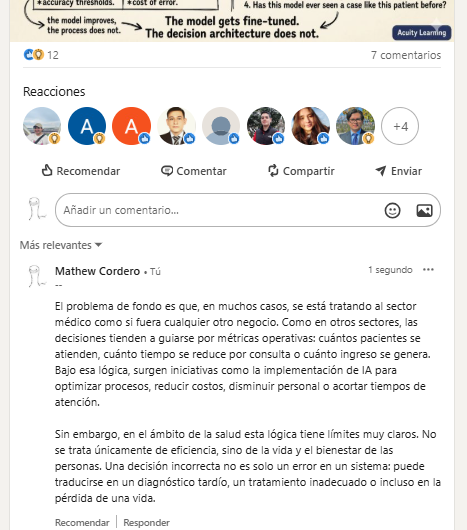

###